In [1]:
import os

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')

In [3]:
os.getcwd()

'C:\\Users\\Malay'

In [4]:
pwd

'C:\\Users\\Malay'

# Loding and Understanding the data

## We load gender_submission to understand testing accuracy

In [5]:
import pandas as pd

In [6]:
df = pd.read_csv(r"C:\Users\Malay\OneDrive\Desktop\Predective Analytics\Datasets\train - train.csv")
# Loading testing data
x_test = pd.read_csv(r"C:\Users\Malay\OneDrive\Desktop\Predective Analytics\Datasets\test - test.csv")
y_test = pd.read_csv(r"C:\Users\Malay\OneDrive\Desktop\Predective Analytics\Datasets\gender_submission - gender_submission.csv")

In [7]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [8]:
y_test

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [9]:
x_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [10]:
passengerId = x_test['PassengerId']

In [11]:
passengerId.head()

0    892
1    893
2    894
3    895
4    896
Name: PassengerId, dtype: int64

In [12]:
print('x_train')
df.info()
print('-'*70)
print('x_test')
x_test.info()

x_train
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
----------------------------------------------------------------------
x_test
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------

In [13]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
x_test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [15]:
y_test.describe()

,PassengerId,Survived
count,418.000000,418.000000
mean,1100.500000,0.363636
std,120.810458,0.481622
min,892.000000,0.000000
25%,996.250000,0.000000
50%,1100.500000,0.000000
75%,1204.750000,1.000000
max,1309.000000,1.000000


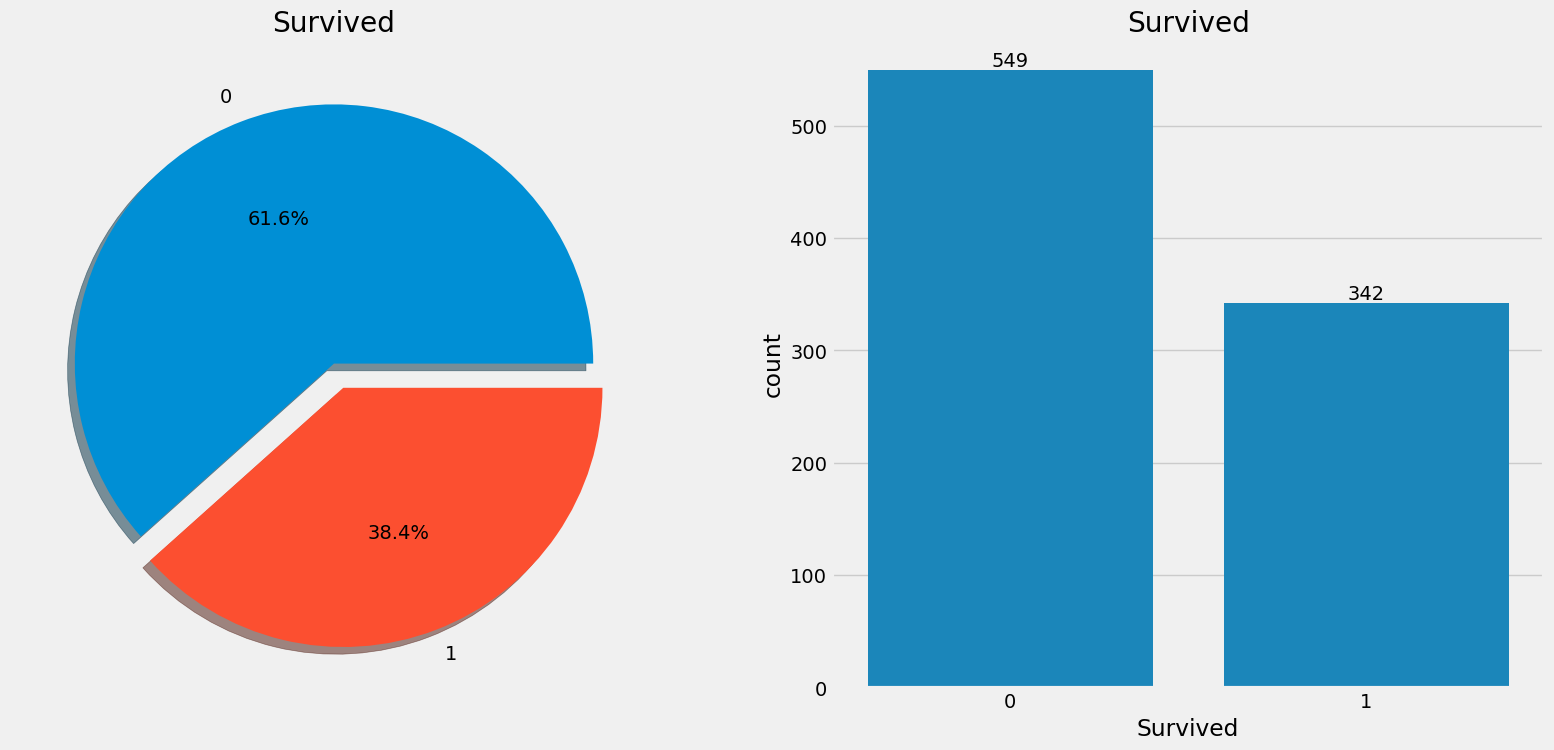

In [16]:
f,ax=plt.subplots(1,2,figsize=(18,8))

df['Survived'].value_counts().plot.pie(
    explode=[0,0.1],
    autopct='%1.1f%%',
    ax=ax[0],
    shadow=True
)

ax[0].set_title('Survived')

ax[0].set_ylabel('')

sns.countplot(x='Survived',
              data=df,
              ax=ax[1]
             )

ax[1].bar_label(ax[1].containers[0])

ax[1].set_title('Survived')

plt.show()

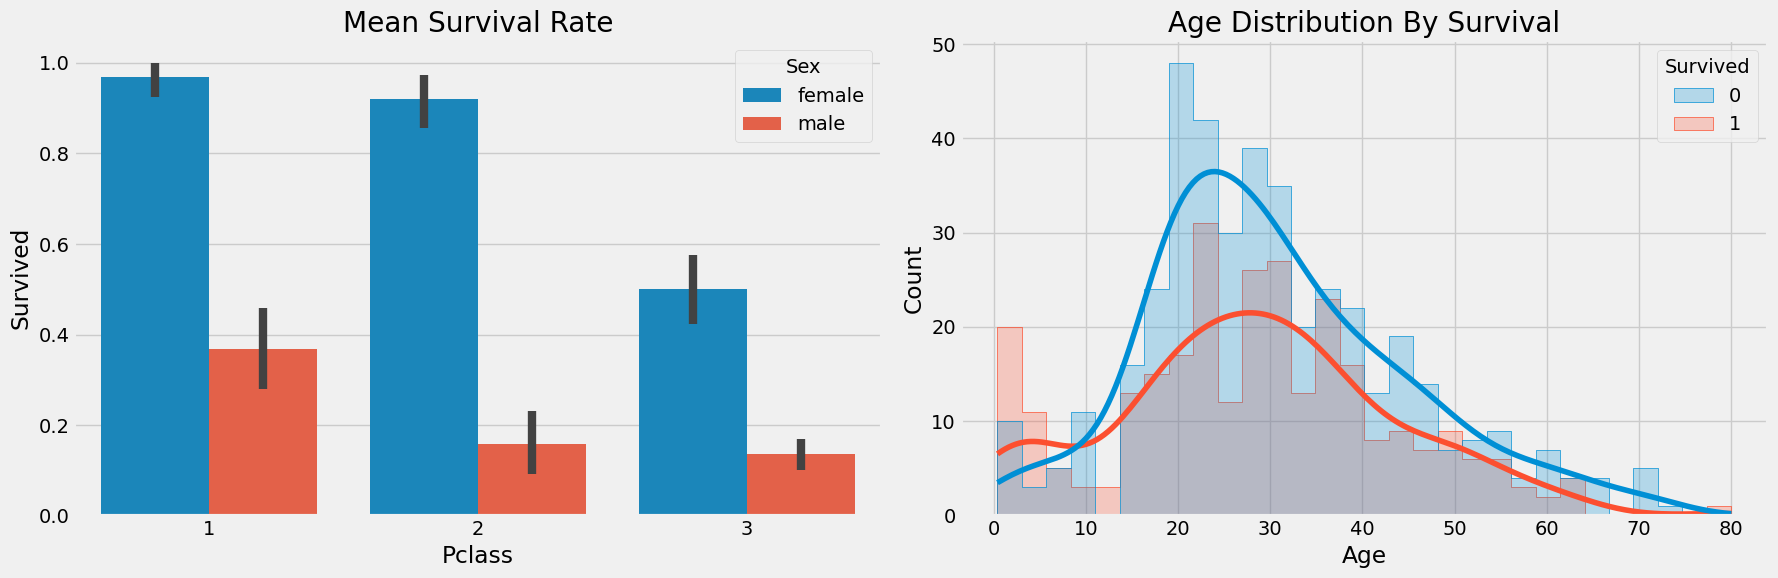

In [17]:
fig, ax = plt.subplots(1,2,figsize=(18,6))
sns.barplot(data=df,x='Pclass', y = 'Survived', hue='Sex', ax=ax[0])
ax[0].set_title('Survival rate by Sex & Class')
ax[0].set_title('Mean Survival Rate')
sns.histplot(data = df, x='Age', hue='Survived', kde=True, bins=30, element='step', ax=ax[1])
ax[1].set_title('Age Distribution By Survival')
plt.tight_layout()
plt.show()

# DATA WRANGLING

In [18]:
df['Initial']=0
for i in df.Name:
    df['Initial']=df.Name.str.extract('([A-Za-z]+)\.') #Lets us extract Salutations

In [19]:
x_test['Initial']=0
for i in x_test.Name:
    x_test['Initial']=x_test.Name.str.extract('([A-Za-z]+)\.') #Lets us extract Salutations

In [20]:
df['Initial'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'Countess',
       'Jonkheer'], dtype=object)

In [21]:
x_test['Initial'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Ms', 'Col', 'Rev', 'Dr', 'Dona'],
      dtype=object)

In [22]:
#Checking the Initials
pd.crosstab(df.Initial,df.Sex).T.style.background_gradient(cmap='summer_r') 

Initial,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Sex,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


In [23]:
df['Initial'].replace(['Mlle','Mme','Ms','Dr','Major','Lady','Countess','Jonkheer','Col','Rev','Capt','Sir','Don'],['Miss','Miss','Miss','Mr','Mr','Mrs','Mrs','Other','Other','Other','Mr','Mr','Mr'],inplace=True)
df['Pclass'].replace([1,2,3],['first','second','third'],inplace=True)
x_test['Initial'].replace(['Mlle','Mme','Ms','Dr','Major','Lady','Countess','Jonkheer','Col','Rev','Capt','Sir','Don','Dona'],['Miss','Miss','Miss','Mr','Mr','Mrs','Mrs','Other','Other','Other','Mr','Mr','Mr','Mrs'],inplace=True)
x_test['Pclass'].replace([1,2,3],['first','second','third'],inplace=True)

In [24]:
#Checking Initials with the same sex
pd.crosstab(df.Initial,df.Sex).T.style.background_gradient(cmap='summer_r')

Initial,Master,Miss,Mr,Mrs,Other
Sex,,,,,
female,0,186,1,127,0
male,40,0,528,0,9


In [25]:
pd.crosstab(x_test.Initial,x_test.Sex).T.style.background_gradient(cmap='summer_r')

Initial,Master,Miss,Mr,Mrs,Other
Sex,,,,,
female,0,79,0,73,0
male,21,0,241,0,4


In [26]:
df.Initial.unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Other'], dtype=object)

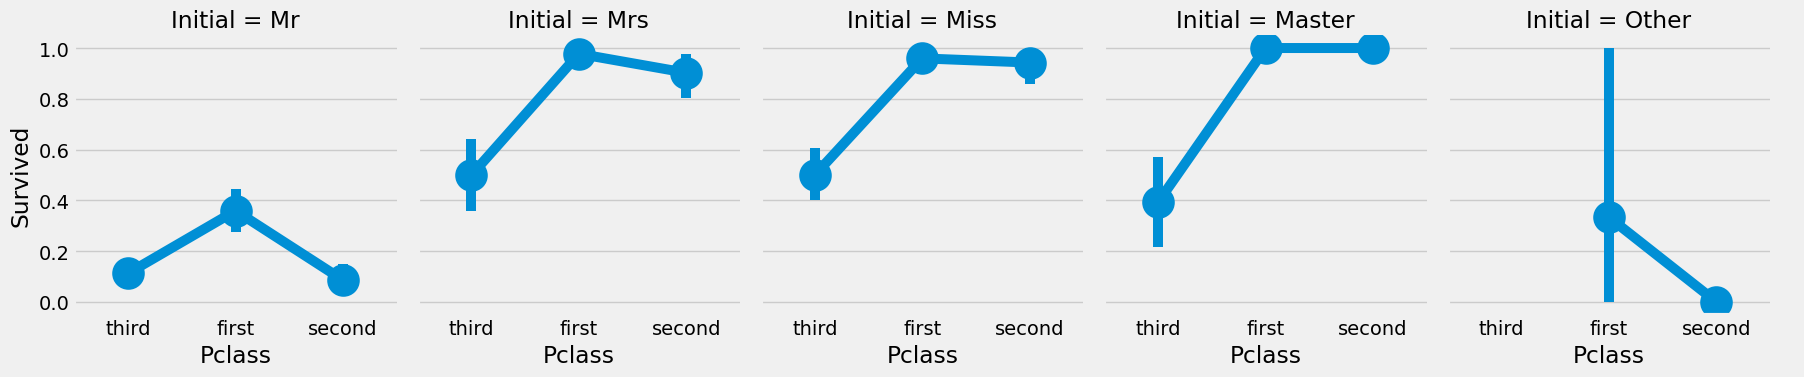

In [27]:
sns.catplot(x='Pclass', y='Survived', col='Initial', data=df, kind='point', height=4, aspect= 0.9)
plt.show()

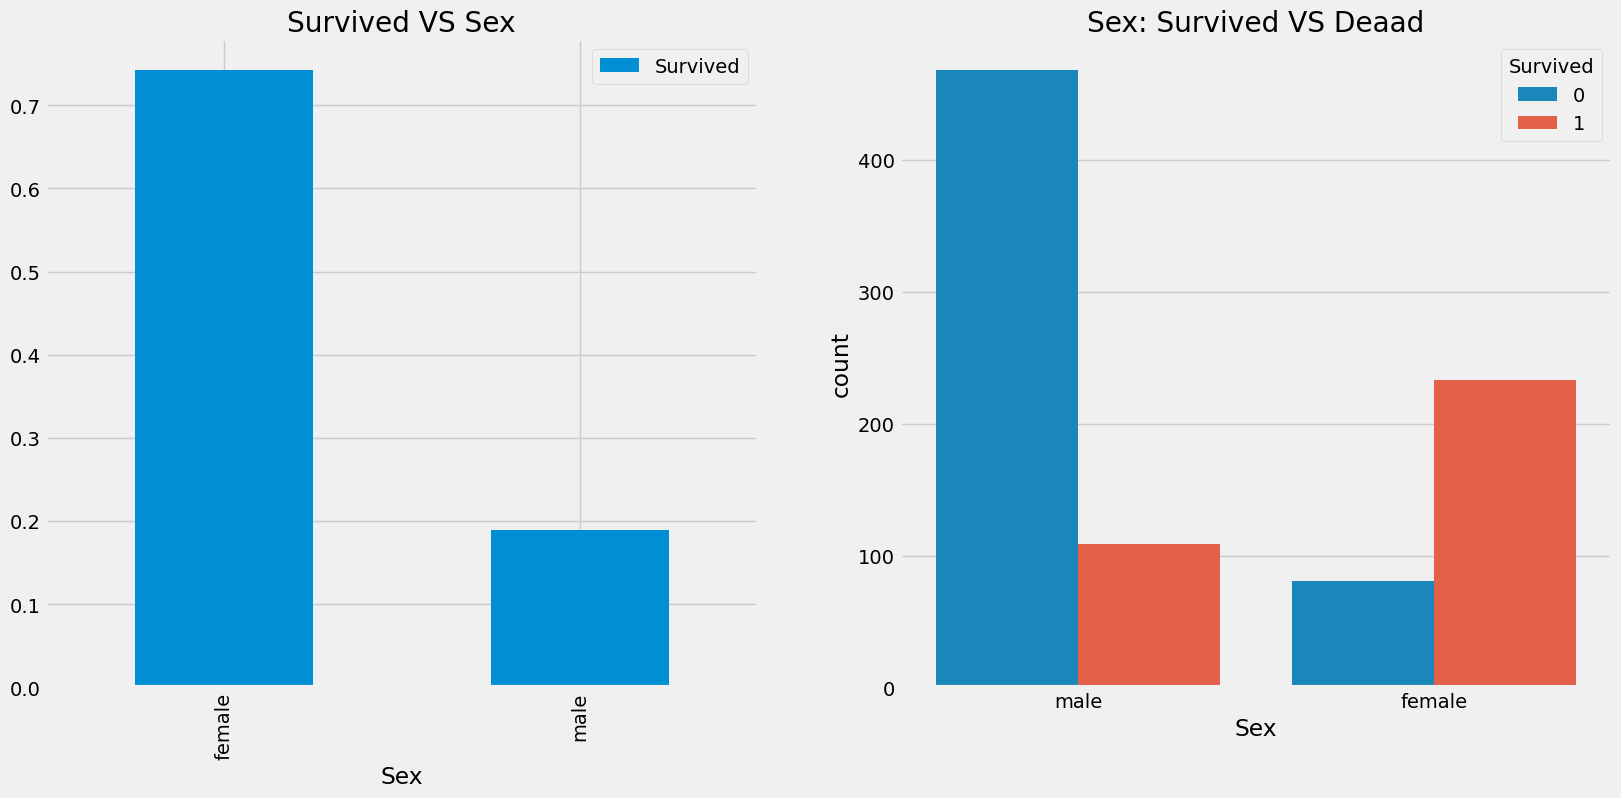

In [28]:
f,ax=plt.subplots(1,2,figsize=(18,8))
df[['Sex','Survived']].groupby(['Sex']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survived VS Sex')
sns.countplot(x='Sex',hue='Survived',data=df,ax=ax[1])
ax[1].set_title('Sex: Survived VS Deaad')
plt.show()

In [29]:
df.groupby('Initial')['Age'].mean()

Initial
Master     4.574167
Miss      21.860000
Mr        32.739609
Mrs       35.981818
Other     45.888889
Name: Age, dtype: float64

In [30]:
x_test.groupby('Initial')['Age'].mean()

Initial
Master     7.406471
Miss      21.774844
Mr        32.114130
Mrs       38.904762
Other     42.750000
Name: Age, dtype: float64

In [31]:
df.loc[(df.Age.isnull())&(df.Initial=='Master'),'Age']=5
df.loc[(df.Age.isnull())&(df.Initial=='Miss'),'Age']=22
df.loc[(df.Age.isnull())&(df.Initial=='Mr'),'Age']=33
df.loc[(df.Age.isnull())&(df.Initial=='Mrs'),'Age']=36
df.loc[(df.Age.isnull())&(df.Initial=='Other'),'Age']=46

In [32]:
x_test.loc[(x_test.Age.isnull())&(df.Initial=='Master'),'Age']=5
x_test.loc[(x_test.Age.isnull())&(df.Initial=='Miss'),'Age']=22
x_test.loc[(x_test.Age.isnull())&(df.Initial=='Mr'),'Age']=33
x_test.loc[(x_test.Age.isnull())&(df.Initial=='Mrs'),'Age']=36
x_test.loc[(x_test.Age.isnull())&(df.Initial=='Other'),'Age']=46

In [33]:
df.Initial.isnull().any()

np.False_

In [34]:
x_test.Initial.isnull().any()

np.False_

In [35]:
print('x_train')
df.info()
print('-'*70)
print('x_test')
x_test.info()

x_train
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  Initial      891 non-null    object 
dtypes: float64(2), int64(4), object(7)
memory usage: 90.6+ KB
----------------------------------------------------------------------
x_test
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column

In [36]:
pd.crosstab([df.Embarked,df.Pclass],[df.Sex,df.Survived],margins=True).style.background_gradient(cmap="summer_r")

In [37]:
df.loc[(df.Embarked.isnull())]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial
61,62,1,first,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,Miss
829,830,1,first,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,Mrs


In [38]:
x_test.loc[(x_test.Embarked.isnull())]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial


In [39]:
df["Embarked"].fillna("S", inplace = True)
x_test["Embarked"].fillna("S", inplace = True)

## CREATING A NEW FEATURE BY APPENDING 'Parch' & 'SibSp'

In [40]:
df['FamilySize'] = df['Parch'] + df['SibSp']
x_test['FamilySize'] = x_test['Parch'] + x_test['SibSp']

## DATA CLEANING

In [41]:
data=df.drop(['PassengerId','Name','Cabin','Ticket','Parch','SibSp'],axis=1,)
x_test=x_test.drop(['PassengerId','Name','Cabin','Ticket','Parch','SibSp'],axis=1,)

In [42]:
data.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Initial,FamilySize
0,0,third,male,22.0,7.2500,S,Mr,1
1,1,first,female,38.0,71.2833,C,Mrs,1
2,1,third,female,26.0,7.9250,S,Miss,0
3,1,first,female,35.0,53.1000,S,Mrs,1
4,0,third,male,35.0,8.0500,S,Mr,0


In [43]:
data.FamilySize.unique()

array([ 1,  0,  4,  2,  6,  5,  3,  7, 10])

In [44]:
data.FamilySize.value_counts().to_frame().style.background_gradient(cmap='summer')

,count
FamilySize,
0,537
1,161
2,102
3,29
5,22
4,15
6,12
10,7
7,6


In [45]:
import numpy as np
z = float('inf')
signoid = 1 / (1 + np.exp(z))
print(signoid)

0.0


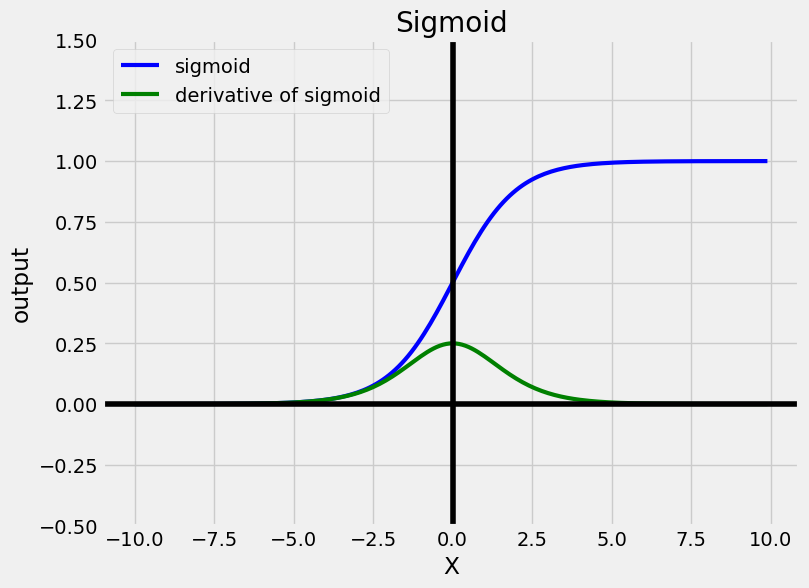

In [46]:
%matplotlib inline
from __future__ import division

import numpy as np
import matplotlib.pyplot as plt


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def grad_sigmoid(x):
    return sigmoid(x) * (1 - sigmoid(x))


X = np.arange(-10, 10, 0.1)

fig = plt.figure(figsize=(8, 6))

plt.plot(X, sigmoid(X), label='sigmoid', c='blue', linewidth=3)

plt.plot(
    X,
    grad_sigmoid(X),
    label='derivative of sigmoid',
    c='green',
    linewidth=3
)

plt.legend(loc='upper left')

plt.xlabel('X')
plt.grid(True)

plt.ylim([-0.5, 1.5])

plt.ylabel('output')
plt.title('Sigmoid')

plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')

plt.show()